## Energy calculation along a route
In this notebook we set up a basic simulation where one vessel moves over a 1D network path consisting of three edges each 100 km long. The middle section has a shallower depth than the other sections. The calculations show the estimated energy consumption along the route.

#### 0. Import libraries

In [1]:
# package(s) used for creating and geo-locating the graph
import networkx as nx
import pyproj
from pyproj import Geod
from shapely.geometry import Point

# package(s) related to the simulation (creating the vessel, running the simulation)
import datetime, time
import simpy
import opentnsim

# package(s) needed for inspecting the output
import pandas as pd

# package(s) needed for plotting
import plotly.graph_objects as go
from plotly.subplots import make_subplots

print("This notebook is executed with OpenTNSim version {}".format(opentnsim.__version__))

This notebook is executed with OpenTNSim version 1.3.7


#### 1. Define object classes

In [2]:
# make your preferred Vessel class out of available mix-ins.
Vessel = type(
    "Vessel", 
    (
        opentnsim.energy.mixins.ConsumesEnergy,
        opentnsim.core.Identifiable,                       # allows to give the object a name and a random ID,
        opentnsim.core.Movable,                            # allows the object to move, with a fixed speed, while logging this activity
        opentnsim.core.vessel_properties.VesselProperties,
        opentnsim.core.ExtraMetadata,
    ), 
    {}
)

#### 2. Create graph
Next we create a network (a graph) along which the vessel can move. This case we create a single edge of 100 km exactly.

In [3]:
# initialize geodetic calculator with WGS84 ellipsoid
geod = Geod(ellps="WGS84")

In [4]:
# starting point (longitude, latitude)
lon0, lat0 = 0, 0

# compute the other point 100 km East from Point 0
lon1, lat1, _ = geod.fwd(lon0, lat0, 90, 100000) # East from Point 0
lon2, lat2, _ = geod.fwd(lon1, lat1, 90, 100000) # East from Point 1
lon3, lat3, _ = geod.fwd(lon2, lat2, 90, 100000) # East from Point 2

# define nodes with their geographic coordinates
coords = {
    "0": (lon0, lat0),
    "1": (lon1, lat1),
    "2": (lon2, lat2),
    "3": (lon3, lat3),
}

In [5]:
# create list of edges
edges = [
    ("0", "1"), ("1", "0"),
    ("1", "2"), ("2", "1"),
    ("2", "3"), ("3", "2"),
] # bi-directional edge

In [6]:
# create a directed graph
FG = nx.DiGraph()

# add nodes
for name, coord in coords.items():
    FG.add_node(name, geometry=Point(coord[0], coord[1]))

# add edges
for edge in edges:
    FG.add_edge(edge[0], edge[1], weight=1)

In [7]:
# extract positions for plotting
positions = {node: (FG.nodes[node]["geometry"].x, FG.nodes[node]["geometry"].y) for node in FG.nodes}

# collect node labels
labels = {node: node for node in FG.nodes}

# compute edge labels as geodesic distances
edge_labels = {}
for u, v in FG.edges():
    lon1, lat1 = positions[u]
    lon2, lat2 = positions[v]
    _, _, dist = geod.inv(lon1, lat1, lon2, lat2)
    edge_labels[(u, v)] = f"{int(dist)} m"

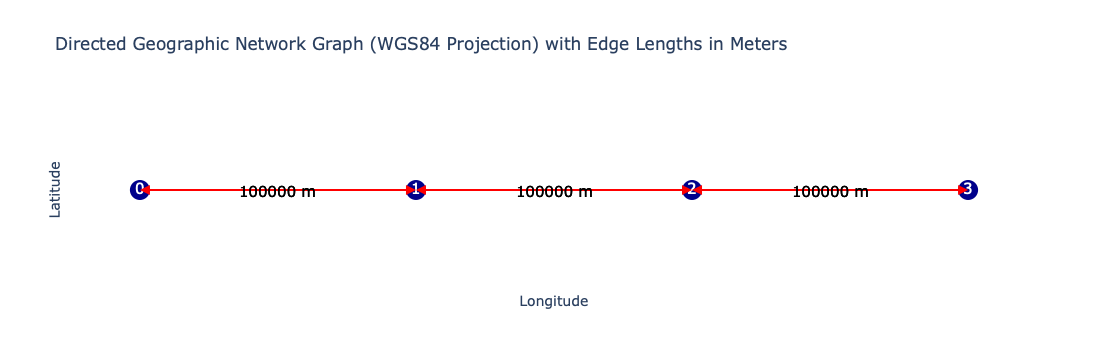

In [8]:
opentnsim.graph.plot_graph(FG)

#### 3. Run simulation

In [9]:
def mission(env, vessel):
    """Method that defines the mission of the vessel. 
    
    In this case: 
        keep moving along the path until its end point is reached
    """
    
    while True:
        yield from vessel.move()
        
        if vessel.geometry == nx.get_node_attributes(env.graph, "geometry")[vessel.route[-1]]:
            break

In [10]:
# start simpy environment
simulation_start = datetime.datetime(2024, 1, 1, 0, 0, 0)
env = simpy.Environment(initial_time=simulation_start.timestamp())
env.epoch = simulation_start

# add graph to environment
FG.edges['0', '1']['GeneralDepth'] = 6
FG.edges['1', '0']['GeneralDepth'] = 6
FG.edges['1', '2']['GeneralDepth'] = 4.5
FG.edges['2', '1']['GeneralDepth'] = 4.5
FG.edges['2', '3']['GeneralDepth'] = 6
FG.edges['3', '2']['GeneralDepth'] = 6
env.graph = FG

# create vessel from a dict 
route = nx.dijkstra_path(env.graph, "0", "3")
data_vessel = {
    "env": env,
    "name": 'Vessel',           # you can give the vessel an arbitratry name
    "type": 'Va/M9 - Verl. Groot Rijnschip', # This indicates the vessel class. This info is mainly informative.
    "L": 110,                   # m
    "B": 11.4,                  # m
    "T": 3.5,                   # m
    "v": 3,                     # m/s If None: this value is calculated based on P_tot_given
    "safety_margin": 0.2,       # for tanker vessel with sandy bed the safety margin is recommended as 0.2 m 
    "h_squat": True,            # if the ship should squat while moving, set to True, otherwise set to False
    "P_installed": 1750.0,      # kW
    "P_tot_given": None,        # kW If None: this value is calculated value based on speed
    "bulbous_bow": False,       # if a vessel has no bulbous_bow, set to False; otherwise set to True.
    "P_hotel_perc": 0.05,       # 0: all power goes to propulsion
    "P_hotel": None,            # None: calculate P_hotel from percentage
    "x": 2,                     # number of propellers
    "L_w": 3.0 ,
    "C_B": 0.85,                # block coefficient 
    "C_year": 1990,             # engine build year
    "arrival_time": datetime.datetime(2024, 1, 1, 0, 0, 0),
    "geometry": env.graph.nodes[route[0]]['geometry'],
    "route": route,             # the route to sail
}  # 

# create an instance of the Vessel class using the input dict data_vessel
vessel = Vessel(**data_vessel)

# start the simulation
env.process(mission(env, vessel))
env.run()

#### 4. Inspect output
We can now inspect  the simulation output by inspecting the _vessel.logbook_. Note that the _Log_ mix-in was included when we added _Movable_. The _vessel.logbook_ keeps track of the moving activities of the vessel. For each discrete event OpenTNSim logs an event message, the start/stop time and the location. The _vessel.logbook_ is of type dict. For convenient inspection it can be loaded into a Pandas dataframe. 

In [11]:
# load the logbook data into a dataframe
df = pd.DataFrame.from_dict(vessel.logbook)

display(df)

,Message,Timestamp,Value,Geometry
0,Sailing from node 0 to node 1 start,2024-01-01 00:00:00.000000,0,POINT (0 0)
1,Sailing from node 0 to node 1 stop,2024-01-01 09:15:33.333333,0,POINT (0.8983152841195217 0)
2,Sailing from node 1 to node 2 start,2024-01-01 09:15:33.333333,0,POINT (0.8983152841195217 0)
3,Sailing from node 1 to node 2 stop,2024-01-01 18:31:06.666667,0,POINT (1.7966305682390433 0)
4,Sailing from node 2 to node 3 start,2024-01-01 18:31:06.666667,0,POINT (1.7966305682390433 0)
5,Sailing from node 2 to node 3 stop,2024-01-02 03:46:40.000000,0,POINT (2.6949458523585648 0)


The inspection of the logbook data shows that Vessel moved from its origin (*Node 0*) to its destination (*Node 1*). The print statements show that the length of the route from *Node 0* to *Node 1* is exactly 100 km. At a given speed of 1 m/s the trip duration should be exactly 100000 seconds, as is indeed shown to be the case.

In [12]:
# TODO: naar de package verplaatsen - mogelijk in een log module plaatsen
def logbook_to_eventtable(objs):
    """Method to transform object logbook, that contains a list of activity start/stop logs, into a 'minimum event table'. 
    
    This method implements the basic 'event table' concept as proposed by Van der Werff:

    Van der Werff, S.E., F. Baart and M. van Koningsveld (2025). “Merging Multiple System Perspectives: The Key to 
    Effective Inland Shipping Emission-Reduction Policy Design.” Journal of Marine Science and engineering 13(4), 716. 
    https://doi.org/10.3390/jmse13040716 

    Van der Werff, S.E., S. Eppenga, A. van der Hout, F. Baart and M. van Koningsveld (2025). “Multi-perspective 
    nautical safety risk assessment of allisions with offshore wind parks.” Applied Ocean Research 158(2025),104564. 
    https://doi.org/10.1016/j.apor.2025.104564 

    For waterborne traffic travelling over a water transport network, a unique event is defined by a combination of: 
     - a unique vessel, 
     - that travels a specific section of the waterway, 
     - at a specific time.

    Parameters
    ----------
    objs: list
        list of OpenTNSim simulation objects that have log information

    Returns
    -------
    df: pandas.DataFrame
        dataframe that contains all events encapsulated in the obj.logbook attributes in the input list of objs
    """
    
    events = []
    for obj in objs:
        df = pd.DataFrame.from_dict(obj.logbook)
        for i in range(0, len(df), 2):
            activity = df.iloc[i]['Message'].replace(' start', '')
            
            start_time = df.iloc[i]['Timestamp']
            stop_time = df.iloc[i+1]['Timestamp']
            start_location = df.iloc[i]['Geometry']
            stop_location = df.iloc[i+1]['Geometry']
            
            duration_seconds = (stop_time - start_time).total_seconds()
            distance_meters = opentnsim.graph.calculate_distance(start_location, stop_location)
            
            events.append({
                'object id': obj.id,
                'object name': obj.name,
                'activity name': activity,
                'start location': start_location,
                'stop location': stop_location,
                'start time': start_time,
                'stop time': stop_time,
                'distance (m)': distance_meters,
                'duration (s)': duration_seconds,
            })
        
    # Final DataFrame
    df = pd.DataFrame(events)
    
    return df

In [13]:
df_eventtable = logbook_to_eventtable([vessel])
df_eventtable

,object id,object name,activity name,start location,stop location,start time,stop time,distance (m),duration (s)
0,d0350a41-701c-41c1-a5ec-8b5b61149087,Vessel,Sailing from node 0 to node 1,POINT (0 0),POINT (0.8983152841195217 0),2024-01-01 00:00:00.000000,2024-01-01 09:15:33.333333,100000.0,33333.333333
1,d0350a41-701c-41c1-a5ec-8b5b61149087,Vessel,Sailing from node 1 to node 2,POINT (0.8983152841195217 0),POINT (1.7966305682390433 0),2024-01-01 09:15:33.333333,2024-01-01 18:31:06.666667,100000.0,33333.333334
2,d0350a41-701c-41c1-a5ec-8b5b61149087,Vessel,Sailing from node 2 to node 3,POINT (1.7966305682390433 0),POINT (2.6949458523585648 0),2024-01-01 18:31:06.666667,2024-01-02 03:46:40.000000,100000.0,33333.333333


In [14]:
# TODO: naar de package verplaatsen - mogelijk in de energy module houden
def add_energy_attributes_to_eventtable(df, objs):
    """Method to adds attributes to a 'minimum event table'. 
    
    When a vessel object was made with the ConsumesEnergy and VesselProperties mixins, and the path along the graph
    contains Info - Generaldepth information, the energy module can calculate:
     - the resistance components that are associated with passing an edge at a given speed,
     - the power that is needed to overcome that resistance
     - the energy that is consumed to deliver that power.
    
    This method takes a 'minimum event table' and a list of objs as input, and returns an event table with resistance, 
    power and energy attributes.
    :

    Van der Werff, S.E., F. Baart and M. van Koningsveld (2025). “Merging Multiple System Perspectives: The Key to 
    Effective Inland Shipping Emission-Reduction Policy Design.” Journal of Marine Science and engineering 13(4), 716. 
    https://doi.org/10.3390/jmse13040716 

    Van der Werff, S.E., S. Eppenga, A. van der Hout, F. Baart and M. van Koningsveld (2025). “Multi-perspective 
    nautical safety risk assessment of allisions with offshore wind parks.” Applied Ocean Research 158(2025),104564. 
    https://doi.org/10.1016/j.apor.2025.104564 

    For waterborne traffic travelling over a water transport network, a unique event is defined by a combination of: 
     - a unique vessel, 
     - that travels a specific section of the waterway, 
     - at a specific time.

    Parameters
    ----------
    df: pandas.DataFrame
        dataframe that contains the elements of a 'minimum event table'
    objs: list
        list of OpenTNSim simulation objects that have log information

    Returns
    -------
    df: pandas.DataFrame
        dataframe that ccontains the elements of a 'minimum event table' plus energy related attributes
    """
    
    for index, row in df.iterrows():
        
        # the generator option (next) is used to make sure we get the full copy of the object found in the list
        obj = next((x for x in objs if x.id == row['object id']), None)

        # get the depth from the edge sailed in the event (and check if squat effects need to be considered
        h_0 = opentnsim.graph.calculate_depth(row['start location'], row['stop location'], obj.env.graph)
        h_0 = vessel.calculate_h_squat(v=obj.v, h_0=h_0)
        
        obj.calculate_total_resistance(v=obj.v, h_0=h_0)
        obj.calculate_total_power_required(v=obj.v, h_0=h_0)
        obj.calculate_emission_factors_total(v=obj.v, h_0=h_0)
        obj.calculate_SFC_final(v=obj.v, h_0=h_0)

        df.at[index, 'waterdepth (m)'] = h_0
        df.at[index, 'waterway width (m)'] = None
        df.at[index, 'current (m/s)'] = 0
        df.at[index, 'engine age (year)'] = obj.C_year

        df.at[index, 'P_tot (kW)'] = obj.P_tot
        df.at[index, 'P_given (kW)'] = obj.P_given
        df.at[index, 'P_installed (kW)'] = obj.P_installed

        energy_delta = (obj.P_tot * row['duration (s)'] / 3600)  # kJ/3600 = kWh
        df.at[index, 'total_energy (kWh)'] = energy_delta
      
    return df

In [15]:
# add energy attributes to the minimum event table
df_eventtable_energy = add_energy_attributes_to_eventtable(df_eventtable, [vessel])        

pd.set_option('display.max_columns', None)
df_eventtable_energy

,object id,object name,activity name,start location,stop location,start time,stop time,distance (m),duration (s),waterdepth (m),waterway width (m),current (m/s),engine age (year),P_tot (kW),P_given (kW),P_installed (kW),total_energy (kWh)
0,d0350a41-701c-41c1-a5ec-8b5b61149087,Vessel,Sailing from node 0 to node 1,POINT (0 0),POINT (0.8983152841195217 0),2024-01-01 00:00:00.000000,2024-01-01 09:15:33.333333,100000.0,33333.333333,5.867175,None,0.0,1990.0,295.821975,295.821975,1750.0,2739.092363
1,d0350a41-701c-41c1-a5ec-8b5b61149087,Vessel,Sailing from node 1 to node 2,POINT (0.8983152841195217 0),POINT (1.7966305682390433 0),2024-01-01 09:15:33.333333,2024-01-01 18:31:06.666667,100000.0,33333.333334,4.332320,None,0.0,1990.0,314.059932,314.059932,1750.0,2907.962335
2,d0350a41-701c-41c1-a5ec-8b5b61149087,Vessel,Sailing from node 2 to node 3,POINT (1.7966305682390433 0),POINT (2.6949458523585648 0),2024-01-01 18:31:06.666667,2024-01-02 03:46:40.000000,100000.0,33333.333333,5.867175,None,0.0,1990.0,295.821975,295.821975,1750.0,2739.092363


In [16]:
# TODO: naar de package verplaatsen - mogelijk in de energy module houden
def add_fuel_attributes_to_event_table(df, objs):
    """Method to adds fuel related attributes to a 'minimum event table' plus energy attributes. 
    
    When we have an event table that includes energy attributes, we can add fuel related attributes. Depending on the 
    energy carrier and the energy converter, we can estimate:
     - fuel consumption
     - emissions

    Parameters
    ----------
    df: pandas.DataFrame
        dataframe that contains the elements of a 'minimum event table' plus energy related attributes
    objs: list
        list of OpenTNSim simulation objects that have log information

    Returns
    -------
    df: pandas.DataFrame
        dataframe that ccontains a 'minimum event table' plus energy related and fuel related attributes
    """
    
    for index, row in df.iterrows():

        # the generator option (next) is used to make sure we get the full copy of the object found in the list
        obj = next((x for x in objs if x.id == row['object id']), None)

        diesel_C_year = row['total_energy (kWh)'] * obj.final_SFC_diesel_C_year_ICE_mass 
        
        df.at[index, 'diesel_consumption (g)'] = diesel_C_year
        df.at[index, 'diesel_consumption_m (g/m)'] = diesel_C_year / row['distance (m)']
        df.at[index, 'diesel_consumption_s (g/s)'] = diesel_C_year / row['duration (s)']

        CO2_emission_total = row['total_energy (kWh)'] * obj.total_factor_CO2 # in g (total_factor is the Emission Factor)                                                                                              #stationary phase # in g
        PM10_emission_total = row['total_energy (kWh)'] * obj.total_factor_PM10 # in g
        NOX_emission_total = row['total_energy (kWh)'] * obj.total_factor_NOX # in g

        df.at[index, 'CO2_emission_total (g)'] = CO2_emission_total
        df.at[index, 'PM10_emission_total (g)'] = PM10_emission_total
        df.at[index, 'NOX_emission_total (g)'] = NOX_emission_total

        # TODO: overweeg of deze entries nuttig zijn. Ze zijn ook eenvoudig te berekenen uit andere entries
        df.at[index, 'CO2_emission_per_m (g/m)'] = CO2_emission_total / row['distance (m)']
        df.at[index, 'PM10_emission_per_m (g/m)'] = PM10_emission_total / row['distance (m)']
        df.at[index, 'NOX_emission_per_m (g/m)'] = NOX_emission_total / row['distance (m)']

        # TODO: overweeg of deze entries nuttig zijn. Ze zijn ook eenvoudig te berekenen uit andere entries
        df.at[index, 'CO2_emission_per_s (g/s)'] = CO2_emission_total / row['duration (s)']
        df.at[index, 'PM10_emission_per_s (g/s)'] = PM10_emission_total / row['duration (s)']
        df.at[index, 'NOX_emission_per_s (g/s)'] = NOX_emission_total / row['duration (s)']
      
    return df

In [17]:
# add fuel attributes to the minimum event table with energy attributes
df_eventtable_energy_fuel = add_fuel_attributes_to_event_table(df_eventtable_energy, [vessel])

pd.set_option('display.max_columns', None)
df_eventtable_energy_fuel

,object id,object name,activity name,start location,stop location,start time,stop time,distance (m),duration (s),waterdepth (m),waterway width (m),current (m/s),engine age (year),P_tot (kW),P_given (kW),P_installed (kW),total_energy (kWh),diesel_consumption (g),diesel_consumption_m (g/m),diesel_consumption_s (g/s),CO2_emission_total (g),PM10_emission_total (g),NOX_emission_total (g),CO2_emission_per_m (g/m),PM10_emission_per_m (g/m),NOX_emission_per_m (g/m),CO2_emission_per_s (g/s),PM10_emission_per_s (g/s),NOX_emission_per_s (g/s)
0,d0350a41-701c-41c1-a5ec-8b5b61149087,Vessel,Sailing from node 0 to node 1,POINT (0 0),POINT (0.8983152841195217 0),2024-01-01 00:00:00.000000,2024-01-01 09:15:33.333333,100000.0,33333.333333,5.867175,None,0.0,1990.0,295.821975,295.821975,1750.0,2739.092363,704183.863338,7.041839,21.125516,2.234183e+06,1391.999141,31630.376955,22.341833,0.013920,0.316304,67.025500,0.041760,0.948911
1,d0350a41-701c-41c1-a5ec-8b5b61149087,Vessel,Sailing from node 1 to node 2,POINT (0.8983152841195217 0),POINT (1.7966305682390433 0),2024-01-01 09:15:33.333333,2024-01-01 18:31:06.666667,100000.0,33333.333334,4.332320,None,0.0,1990.0,314.059932,314.059932,1750.0,2907.962335,747598.065358,7.475981,22.427942,2.371925e+06,1477.818392,33580.446599,23.719248,0.014778,0.335804,71.157743,0.044335,1.007413
2,d0350a41-701c-41c1-a5ec-8b5b61149087,Vessel,Sailing from node 2 to node 3,POINT (1.7966305682390433 0),POINT (2.6949458523585648 0),2024-01-01 18:31:06.666667,2024-01-02 03:46:40.000000,100000.0,33333.333333,5.867175,None,0.0,1990.0,295.821975,295.821975,1750.0,2739.092363,704183.863338,7.041839,21.125516,2.234183e+06,1391.999141,31630.376955,22.341833,0.013920,0.316304,67.025500,0.041760,0.948911


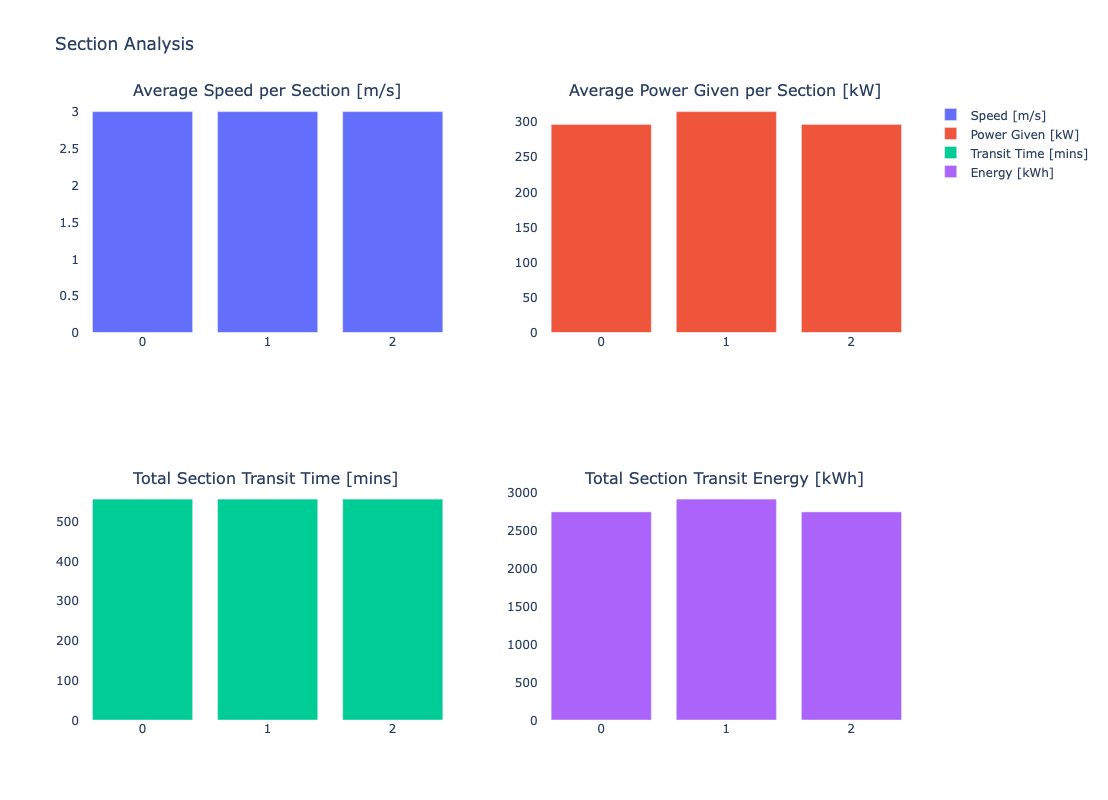

In [18]:
# Calculate average speed
average_speed = df_eventtable_energy_fuel['distance (m)'] / df_eventtable_energy_fuel['duration (s)']

# Calculate durations in minutes
durations = [
    (row['stop time'] - row['start time']).total_seconds() / 60
    for _, row in df_eventtable_energy_fuel.iterrows()
]

# Create 2x2 subplot figure
fig = make_subplots(rows=2, cols=2, subplot_titles=[
    'Average Speed per Section [m/s]',
    'Average Power Given per Section [kW]',
    'Total Section Transit Time [mins]',
    'Total Section Transit Energy [kWh]'
])

# Add bar charts to subplots
fig.add_trace(go.Bar(x=df.index, y=average_speed, name='Speed [m/s]'), row=1, col=1)
fig.add_trace(go.Bar(x=df.index, y=df_eventtable_energy_fuel['P_given (kW)'], name='Power Given [kW]'), row=1, col=2)
fig.add_trace(go.Bar(x=df.index, y=durations, name='Transit Time [mins]'), row=2, col=1)
fig.add_trace(go.Bar(x=df.index, y=df_eventtable_energy_fuel['total_energy (kWh)'], name='Energy [kWh]'), row=2, col=2)

# Update layout
fig.update_layout(
    height=800,
    width=1000,
    title_text='Section Analysis',
    plot_bgcolor='white'
)

fig.show()